## Packages Installation

In [1]:
%pip install spacy
%pip install nltk  
## the above command for nltk only installs the package partially, so to have all features, nltk.download("all")

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import nltk
import spacy 
nltk.download("all")

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to
[nltk_data]    |     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package alpino to
[nltk_data]    |     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]    |   Package alpino is already up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_eng is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]    |

True

## Data Importing

In [3]:
twitter_data=pd.read_csv("https://raw.githubusercontent.com/venkatareddykonasani/Datasets/master/Twitter_Sentiment/Twitter_Sentiment_Data.csv")
twitter_data.sample(10)

,tweet_ID,raw_tweet,sentiment_label
4987,9870d532a6,Gone have my ears on it when I am at home ..p...,neutral
6859,2c2b831a36,Yes sir...I just acquired a Master of Arts in...,positive
22351,8e6ba09a14,they shot him he was still alive too...,neutral
4280,683c467d2a,i tried listenin to music 4 half an hour! Tri...,negative
3992,ea59c43f43,They gave me a regular coke instead of diet. R...,neutral
26935,9bb2417f44,I saw the pic. You surely don`t look like Ami...,neutral
18603,1e7e636278,hahah i sowwie hun whats up thoe ?,neutral
3849,98fe43fcae,can`t sleep throat dry as hell.. ugh ! still g...,neutral
6079,456c4304cd,first weekend at home,neutral
5955,c660632bdd,"_warwounds_C I feel ya pain, I`ve got myself a...",neutral


## Lower Case Conversion

In [4]:
twitter_data["tweet_lowcase"]=twitter_data["raw_tweet"].apply(lambda x:str(x).lower())   
#lambda function to apply on all rows
# str(x) is used to avoid errors due to NaN and numeric values

twitter_data.sample(10)

,tweet_ID,raw_tweet,sentiment_label,tweet_lowcase
11757,1fc4902f30,Skipping school like all the cool kids do,positive,skipping school like all the cool kids do
19769,c7571164b4,"Oh ****.... Here goes my head again, 'I`m Spin...",negative,"oh ****.... here goes my head again, 'i`m spin..."
18578,b73bd70b63,bored well its not like any one can see this i...,negative,bored well its not like any one can see this i...
5945,81f6f8ff89,I couldnt come to see you in Southend on the ...,neutral,i couldnt come to see you in southend on the ...
15216,23186e73f2,have an amazing time with your mommas tomorro...,negative,have an amazing time with your mommas tomorro...
24524,5bd5c5212d,sabi ko nga lighting up is hazardous to your h...,neutral,sabi ko nga lighting up is hazardous to your h...
24840,883887be88,A year from now is graduation....i am pretty s...,negative,a year from now is graduation....i am pretty s...
8901,bdf92841b5,Watched Coraline last night. It was really goo...,positive,watched coraline last night. it was really goo...
22421,58c5ff24c8,thanks gourmetcook! But cold shower wouldn`t h...,negative,thanks gourmetcook! but cold shower wouldn`t h...
17168,86f641a051,Have space right next to the rack for another ...,neutral,have space right next to the rack for another ...


## Tokenizing

In [5]:
from nltk.tokenize import word_tokenize
twitter_data["word_tokens"] = twitter_data["tweet_lowcase"].apply(lambda x:word_tokenize(str(x)))  
# data in word_tokens column will be in list format because the word_tokenize function returns list [one tweet -> many words -> list is necessary]
#lambda function to apply on all rows
#str() function to avoid numeric and other errors

twitter_data[["raw_tweet","word_tokens"]].sample(10)

,raw_tweet,word_tokens
22132,Not enough time for Disney World.... might ju...,"[not, enough, time, for, disney, world, ...., ..."
4828,Morning workout sesh. Love Life.,"[morning, workout, sesh, ., love, life, .]"
1441,heeeey good luck for unair sweet!,"[heeeey, good, luck, for, unair, sweet, !]"
7866,Have fun! Wish your mums a happy mother`s da...,"[have, fun, !, wish, your, mums, a, happy, mot..."
4926,"still babysitting, i want another boost","[still, babysitting, ,, i, want, another, boost]"
7443,"Just got home, doing art all day.. i want to b...","[just, got, home, ,, doing, art, all, day, ..,..."
23605,http://twitpic.com/4whaf Tonight`s art show wa...,"[http, :, //twitpic.com/4whaf, tonight, `, s, ..."
25017,"While on vacation, having golden times spamm...","[while, on, vacation, ,, having, golden, times..."
21577,"Aw man, Half Term isn`t long enough lol!","[aw, man, ,, half, term, isn, `, t, long, enou..."
6437,I don`t mind Sam. But I liked Kate more. I d...,"[i, don, `, t, mind, sam, ., but, i, liked, ka..."


## Expanding shortforms

In [6]:
contra_Expan_Dict = {"ain`t": "am not","aren`t": "are not","can`t": "cannot","can`t`ve": "cannot have","`cause": "because",
"could`ve": "could have","couldn`t": "could not","couldn`t`ve": "could not have","didn`t": "did not",
"doesn`t": "does not","don`t": "do not","hadn`t": "had not","hadn`t`ve": "had not have","hasn`t": "has not",
"haven`t": "have not","he`d": "he would","he`d`ve": "he would have","he`ll": "he will","he`ll`ve": "he will have",
"he`s": "he is","how`d": "how did","how`d`y": "how do you","how`ll": "how will",
"how`s": "how does","i`d": "i would","i`d`ve": "i would have","i`ll": "i will","i`ll`ve": "i will have","i`m": "i am",
"i`ve": "i have","isn`t": "is not","it`d": "it would","it`d`ve": "it would have","it`ll": "it will","it`ll`ve": "it will have",
"it`s": "it is","let`s": "let us","ma`am": "madam","mayn`t": "may not","might`ve": "might have","mightn`t": "might not",
"mightn`t`ve": "might not have","must`ve": "must have","mustn`t": "must not","mustn`t`ve": "must not have","needn`t": "need not","needn`t`ve": "need not have",
"o`clock": "of the clock","oughtn`t": "ought not","oughtn`t`ve": "ought not have","shan`t": "shall not",
"sha`n`t": "shall not","shan`t`ve": "shall not have","she`d": "she would",
"she`d`ve": "she would have","she`ll": "she will","she`ll`ve": "she will have",
"she`s": "she is","should`ve": "should have","shouldn`t": "should not","shouldn`t`ve": "should not have","so`ve": "so have","so`s": "so is",
"that`d": "that would","that`d`ve": "that would have","that`s": "that is","there`d": "there would","there`d`ve": "there would have","there`s": "there is",
"they`d": "they would","they`d`ve": "they would have","they`ll": "they will","they`ll`ve": "they will have","they`re": "they are","they`ve": "they have",
"to`ve": "to have","wasn`t": "was not"," u ": " you "," ur ": " your "," n ": " and ","won`t": "would not",
"dis": "this","bak": "back","brng": "bring"}

In [7]:
# the function checks word in the above dict and replaces it with it's expanded form if present otherwise keeps the word as it is
def expanded_form(x):
    if x in contra_Expan_Dict.keys():
        return(contra_Expan_Dict[x])
    else:
        return(x)

In [8]:
# Application of the above function on a sample tweet
x=str(twitter_data["tweet_lowcase"][6207])
print("original tweet ==>", x)
x=x.split()
print(x)
print("Expanded form ==>",[expanded_form(t) for t in x])

original tweet ==>  it`s under a honeymoon by the good life
['it`s', 'under', 'a', 'honeymoon', 'by', 'the', 'good', 'life']
Expanded form ==> ['it is', 'under', 'a', 'honeymoon', 'by', 'the', 'good', 'life']


In [9]:
twitter_data["tweet_expanded"]=twitter_data["tweet_lowcase"].apply(lambda x:[expanded_form(t) for t in str(x).split()])
twitter_data[["raw_tweet","tweet_expanded"]].sample(10)

,raw_tweet,tweet_expanded
8073,Rachael makes me want to cry,"[rachael, makes, me, want, to, cry]"
17829,"watching #f1. I live near Montmelï¿½, I`m so e...","[watching, #f1., i, live, near, montmelï¿½,, i..."
5001,But i dont mind the long line when theres a su...,"[but, i, dont, mind, the, long, line, when, th..."
6668,Would like some Nutella. None to be had,"[would, like, some, nutella., none, to, be, had]"
3500,i love the music video of you belong with me b...,"[i, love, the, music, video, of, you, belong, ..."
16467,"Hee Hee! I only holiday in the gutter, try to...","[hee, hee!, i, only, holiday, in, the, gutter,..."
4983,is that teh part where hes liek feeling the g...,"[is, that, teh, part, where, hes, liek, feelin..."
11736,getting ready for school.. reading what`s goin...,"[getting, ready, for, school.., reading, what`..."
11446,rblpnBro Not quite where I need to be here .....,"[rblpnbro, not, quite, where, i, need, to, be,..."
15829,I made this huge revelation as I was doing the...,"[i, made, this, huge, revelation, as, i, was, ..."


## Stopwords Removal

### NLTK Stopwords

In [10]:
from nltk.corpus import stopwords
nltk_stop_words = set(stopwords.words('english')) ##Selecting the stop words from the Language
print("Number of Stop words in NLTK ==>", len(nltk_stop_words))
print(sorted(nltk_stop_words))

Number of Stop words in NLTK ==> 198
['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", "he's", 'her', 'here', 'hers', 'herself', 'him', 'himself', 'his', 'how', 'i', "i'd", "i'll", "i'm", "i've", 'if', 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're'

In [11]:
twitter_data["After_Removing_Stopwords_nltk"] = twitter_data["tweet_expanded"].apply(lambda x:[t for t in x if t not in nltk_stop_words ])
twitter_data[["raw_tweet","After_Removing_Stopwords_nltk"]].sample(10)

,raw_tweet,After_Removing_Stopwords_nltk
12512,Margaritas with my Momo. I`ve missed her.,"[margaritas, momo., i have, missed, her.]"
21215,I break some rules and don`t take tension for...,"[break, rules, do not, take, tension, .....]"
9714,needs a little lie down. not feeling great tod...,"[needs, little, lie, down., feeling, great, to..."
23028,I think you are super cute...,"[think, super, cute...]"
3024,good weekend,"[good, weekend]"
5995,sprained my ankle like really badly and tore ...,"[sprained, ankle, like, really, badly, tore, s..."
24145,happy mothers day to all..im gonna help mine r...,"[happy, mothers, day, all..im, gonna, help, mi..."
4549,"I would do a #FollowFriday, but everyone on my...","[would, #followfriday,, everyone, list, alread..."
13218,she`s hot What is up w/ all the unknown f...,"[she is, hot, w/, unknown, followers?, i have,..."
18501,Thank you! I appreciate that.,"[thank, you!, appreciate, that.]"


### spaCy Stopwords

In [12]:
from spacy.lang.en.stop_words import STOP_WORDS as spacy_stopwords
print("Number of Stop words in spaCy ==>", len(spacy_stopwords))
print(sorted(spacy_stopwords))
#Spacy stopwords list looks better.

Number of Stop words in spaCy ==> 326
["'d", "'ll", "'m", "'re", "'s", "'ve", 'a', 'about', 'above', 'across', 'after', 'afterwards', 'again', 'against', 'all', 'almost', 'alone', 'along', 'already', 'also', 'although', 'always', 'am', 'among', 'amongst', 'amount', 'an', 'and', 'another', 'any', 'anyhow', 'anyone', 'anything', 'anyway', 'anywhere', 'are', 'around', 'as', 'at', 'back', 'be', 'became', 'because', 'become', 'becomes', 'becoming', 'been', 'before', 'beforehand', 'behind', 'being', 'below', 'beside', 'besides', 'between', 'beyond', 'both', 'bottom', 'but', 'by', 'ca', 'call', 'can', 'cannot', 'could', 'did', 'do', 'does', 'doing', 'done', 'down', 'due', 'during', 'each', 'eight', 'either', 'eleven', 'else', 'elsewhere', 'empty', 'enough', 'even', 'ever', 'every', 'everyone', 'everything', 'everywhere', 'except', 'few', 'fifteen', 'fifty', 'first', 'five', 'for', 'former', 'formerly', 'forty', 'four', 'from', 'front', 'full', 'further', 'get', 'give', 'go', 'had', 'has', 'ha

In [13]:
# example of removing stopwords using spacy stopwords list
x= ['i', 'saw', 'it', 'the', 'moive', 'is', 'pathetic']
print("original tweet ==>", x)
print("After Removing Stopwords ==>",[t for t in x if t not in spacy_stopwords])

original tweet ==> ['i', 'saw', 'it', 'the', 'moive', 'is', 'pathetic']
After Removing Stopwords ==> ['saw', 'moive', 'pathetic']


In [14]:
twitter_data["After_Removing_Stopwords"] = twitter_data["tweet_expanded"].apply(lambda x:[t for t in x if t not in spacy_stopwords ])
twitter_data[["raw_tweet","After_Removing_Stopwords"]].sample(10)

,raw_tweet,After_Removing_Stopwords
7406,yeah !!,"[yeah, !!]"
6407,Beautiful morning here in the mountains,"[beautiful, morning, mountains]"
15892,: I love camp fires I just wish the kids woul...,"[:, love, camp, fires, wish, kids, try, bit, h..."
21650,heeey heeey! about to go read...,"[heeey, heeey!, read...]"
18451,How can it be so freaking difficult to get a s...,"[freaking, difficult, system-wide, spellchecke..."
25803,"Woken up finally after a long night out, tea, ...","[woken, finally, long, night, out,, tea,, toas..."
11783,my sensors don`t seem to want to last for more...,"[sensors, do not, want, 3, 1/2, days]"
18763,"If all goes according to plan, you CSE RFID gu...","[goes, according, plan,, cse, rfid, guinea, pi..."
7520,Star Trek was GREAT yet minor details needed t...,"[star, trek, great, minor, details, needed, wo..."
1607,"It`s raining cats and dogs in Gda?sk today , l...","[it is, raining, cats, dogs, gda?sk, today, ,,..."


In [15]:
# comparing the output after removing stopwords 
twitter_data[["raw_tweet","tweet_expanded","After_Removing_Stopwords"]].sample(10)

,raw_tweet,tweet_expanded,After_Removing_Stopwords
12076,It`s 4 am and I`m hungry,"[it is, 4, am, and, i am, hungry]","[it is, 4, i am, hungry]"
16162,im glad i dont have to go out...,"[im, glad, i, dont, have, to, go, out...]","[im, glad, dont, out...]"
7768,what a great day,"[what, a, great, day]","[great, day]"
11400,GRANADA BOWL WITH THE CREW! Birthday bowling f...,"[granada, bowl, with, the, crew!, birthday, bo...","[granada, bowl, crew!, birthday, bowling, fisc..."
23824,Just saw my boo he went back to work now time ...,"[just, saw, my, boo, he, went, back, to, work,...","[saw, boo, went, work, time, hair, it is, goin..."
1495,watching crimson tide and eating apple sauce.,"[watching, crimson, tide, and, eating, apple, ...","[watching, crimson, tide, eating, apple, sauce.]"
4236,http://twitpic.com/4w06l - LOVE IT! U have a ...,"[http://twitpic.com/4w06l, -, love, it!, u, ha...","[http://twitpic.com/4w06l, -, love, it!, u, gr..."
18400,Its a lovely 58 degrees right now at 7am. ama...,"[its, a, lovely, 58, degrees, right, now, at, ...","[lovely, 58, degrees, right, 7am., amazing., e..."
21474,GREG D: You should have cried too :L You could...,"[greg, d:, you, should, have, cried, too, :l, ...","[greg, d:, cried, :l, got, through!!, love, gr..."
12893,Nothin better then ridin in a car with your si...,"[nothin, better, then, ridin, in, a, car, with...","[nothin, better, ridin, car, sister, blasting,..."


### Add Custom Stowords

In [16]:
from spacy.lang.en.stop_words import STOP_WORDS as spacy_stopwords
spacy_stopwords.update({"would", "rt","like", "ha", "lol", "need", "do"}) # adding some more words to the existing spacy stopwords list
print("New Number of Stop words in spaCy ==>", len(spacy_stopwords))
print(sorted(spacy_stopwords))

New Number of Stop words in spaCy ==> 331
["'d", "'ll", "'m", "'re", "'s", "'ve", 'a', 'about', 'above', 'across', 'after', 'afterwards', 'again', 'against', 'all', 'almost', 'alone', 'along', 'already', 'also', 'although', 'always', 'am', 'among', 'amongst', 'amount', 'an', 'and', 'another', 'any', 'anyhow', 'anyone', 'anything', 'anyway', 'anywhere', 'are', 'around', 'as', 'at', 'back', 'be', 'became', 'because', 'become', 'becomes', 'becoming', 'been', 'before', 'beforehand', 'behind', 'being', 'below', 'beside', 'besides', 'between', 'beyond', 'both', 'bottom', 'but', 'by', 'ca', 'call', 'can', 'cannot', 'could', 'did', 'do', 'does', 'doing', 'done', 'down', 'due', 'during', 'each', 'eight', 'either', 'eleven', 'else', 'elsewhere', 'empty', 'enough', 'even', 'ever', 'every', 'everyone', 'everything', 'everywhere', 'except', 'few', 'fifteen', 'fifty', 'first', 'five', 'for', 'former', 'formerly', 'forty', 'four', 'from', 'front', 'full', 'further', 'get', 'give', 'go', 'ha', 'had', 

In [17]:
twitter_data["After_Removing_Stopwords"] = twitter_data["tweet_expanded"].apply(lambda x:[t for t in x if t not in spacy_stopwords ])
twitter_data[["raw_tweet","After_Removing_Stopwords"]].sample(10)

,raw_tweet,After_Removing_Stopwords
11873,it was fine. i was still up playing inFamous....,"[fine., playing, infamous., sorry, hear, thing..."
12323,", , and i think you should come home now","[,, ,, think, come, home]"
19192,"i like this new trend , who`s next ? http://t...","[new, trend, ,, who`s, ?, http://tinyurl.com/q..."
17676,Lol... Its NOT the same!!!,"[lol..., same!!!]"
4415,Seesmic Desktop seems pretty good. Nice find,"[seesmic, desktop, pretty, good., nice, find]"
14872,my tummy hurts!,"[tummy, hurts!]"
2151,_58 I also like `Aasman ke paar shaayad`,"[_58, `aasman, ke, paar, shaayad`]"
15349,getting ready to shop birmingham here i come,"[getting, ready, shop, birmingham, come]"
21257,still can`t believe all of the gig posters in ...,"[believe, gig, posters, little, civic, taken, ..."
5170,"Come on bell, RING. I want to go outside.","[come, bell,, ring., want, outside.]"


## Regular Expression

In [18]:
import re

def clean_with_re(x):
    x=str(x)
    x=re.sub(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\(\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+'," ", x) #Remove URLs
    x=re.sub(r'[^\w ]+', "", x) # Remove Punctuation-1
    x=re.sub(r"[,!@&\'?\.$%_]"," ", x) # Remove Punctuation-2
    x=re.sub(r"\d+"," ", x) #Remove digits
    return(x)

In [19]:
twitter_data["tweet_cleaned_Regex"]=twitter_data["After_Removing_Stopwords"].apply(lambda x:clean_with_re(x))
twitter_data[["raw_tweet","tweet_cleaned_Regex"]].sample(10)

,raw_tweet,tweet_cleaned_Regex
7697,is wishing everyone a blessed & beautiful Moth...,wishing blessed beautiful mothers day
414,it means that you are now FAMOUS. Congrats!,means famous congrats
18869,Love that book! My VW I`m about to turn in is...,love book vw i am turn named scout
8166,Really wants to buy new clothes,wants buy new clothes
207,Grabbing coffee from then making mom breakfast,grabbing coffee making mom breakfast
23324,"okay, thanks!",okay thanks
23626,I need to come spend some time on your roof ...,come spend time roof miss double date couple...
1089,wow i have no friends on twitter,wow friends twitter
21691,_B if you`re in leeds you can have one from me,b youre leeds
7363,don`t care about my struggles..,do not care struggles


In [50]:
twitter_data[["After_Removing_Stopwords","tweet_cleaned_Regex"]].sample(10)

,After_Removing_Stopwords,tweet_cleaned_Regex
13140,"[words,, perfect, run,, right?]",words perfect run right
14571,"[i am, town, week, we`ll, party, back., happy,...",i am town week well party back happy early bir...
1443,"[_twitster, ohhhh,, love, morse,, episode, vid...",twitster ohhhh love morse episode video gaze...
9570,"[omg, brings, high, school, days!, ?, http://b...",omg brings high school days ygpg
397,"[hate, dentist]",hate dentist
25892,"[do not, worried!, i am, safe, sound!, <3, you!]",do not worried i am safe sound you
26244,"[myspace, mobile, free?, u, 2, credit..., caus...",myspace mobile free u credit cause liers
7988,"[worried, friend]",worried friend
3465,"[freshman, site., update?, help]",freshman site update help
12553,"[****, maaaaannnn.., holidayzzzzz...]",maaaaannnn holidayzzzzz


## Spelling Correction

In [21]:
%pip install textblob
!python -m textblob.download_corpora

Note: you may need to restart the kernel to use updated packages.
Finished.


[nltk_data] Downloading package brown to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package conll2000 to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package conll2000 is already up-to-date!
[nltk_data] Downloading package movie_reviews to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!


In [22]:
# example of spelling correction using TextBlob on a single sample data point(dataset)
from textblob import TextBlob
sample_tweet="What an grat and amazimg week. I am excited to learn data scienec"
corrected_tweet=TextBlob(sample_tweet).correct()
corrected_tweet

TextBlob("That an great and amazing week. I am excited to learn data science")

## Lemmatization

In [ ]:
%pip install https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.7.1/en_core_web_sm-3.7.1-py3-none-any.whl  # to download the "en_core_web_sm" from spacy-models repo
spacy_model = spacy.load('en_core_web_sm')   # loading en_core_web_sm from spacy model

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     -- ------------------------------------- 0.8/12.8 MB 4.2 MB/s eta 0:00:03
     ----- ---------------------------------- 1.8/12.8 MB 4.2 MB/s eta 0:00:03
     --------- ------------------------------ 2.9/12.8 MB 4.5 MB/s eta 0:00:03
     ------------ --------------------------- 3.9/12.8 MB 4.9 MB/s eta 0:00:02
     --------------- ------------------------ 5.0/12.8 MB 4.8 MB/s eta 0:00:02
     ------------------ --------------------- 6.0/12.8 MB 4.8 MB/s eta 0:00:02
     ---------------------- ----------------- 7.1/12.8 MB 4.8 MB/s eta 0:00:02
     ------------------------- -------------- 8.1/12.8 MB 4.7 MB/s eta 0:00:01
     ---------------------------- ----------- 9.2/12.8 MB 4.8 MB/s eta 0:00:01
     ------------------------------- -------- 10.0/12.8 MB 4.8 MB/s eta 0:00:01
     ---------------------------------- ----- 11.0/12.8 MB 4.8 MB

In [62]:
sample_tweet=twitter_data["tweet_cleaned_Regex"][0]
print("Original Text ==>", sample_tweet)
print("Lemmatization Results ==>", " ".join([t.lemma_ for t in spacy_model(str(sample_tweet))]))

Original Text ==> i would responded going
Lemmatization Results ==> I would respond go


In [47]:
twitter_data["Lemmatized_tweet"] = twitter_data["tweet_cleaned_Regex"].apply(lambda x:" ".join([t.lemma_ for t in spacy_model(str(x))]))  
twitter_data[["raw_tweet","Lemmatized_tweet"]].sample(10)

,raw_tweet,Lemmatized_tweet
3974,- I shall post a notice in town so us Cork la...,shall post notice town cork lady know watch ...
22449,"Awesome sunday service God is for you, Jesus ...",awesome sunday service god you jesus pray ma...
14319,"sad, but true",sad true
7011,wants to go swimming,want swimming
20265,"we dont have the points yet, was talkedabout ...",do not point yet talkedabout ticket drive ca...
22131,I was afraid you were going to say that.,afraid go that
117,hahaa your awesomee !,hahaa awesomee
25877,"yeah, that does sound a bit bad man... i got ...",yeah sound bit bad man get exam week week
7044,sign up for tarte news http://tinyurl.com/dde2...,sign tarte news intro newsletter purchas...
14092,"ooh a storm, that`s always welcome news Happ...",ooh storm that be welcome news happy mother day


In [54]:
#Few more samples
twitter_data[["tweet_cleaned_Regex","Lemmatized_tweet"]].sample(10)

,tweet_cleaned_Regex,Lemmatized_tweet
15114,seen u couple times liked,see u couple time like
10853,hiii freaking love happiest year old girl al...,hiii freaking love happy year old girl aliv...
23643,good morning fourth,good morning fourth
11492,worked tonight work cheesecake ate today pple ...,work tonight work cheesecake eat today pple di...
13881,morning that is mean that is smart,morning that be mean that be smart
21197,look followers tweeps list fully populated,look follower tweep list fully populated
297,im bannished work till,I m bannishe work till
8542,bbqs gone weather stayed good right bonus bed...,bbqs go weather stay good right bonus bed tr...
15715,rickrolld itunes shuffle,rickrolld itune shuffle
13506,long shift tonight sleep i am tired nice talk...,long shift tonight sleep I be tired nice tal...


## Any Further Cleaning

In [60]:
spacy_stopwords.update({"would", "rt","like", "ha", "lol", "need", "do"})
twitter_data["Final_Cleaned_Tweet"] = twitter_data["Lemmatized_tweet"].apply(lambda x:[t for t in str(x).split() if t not in spacy_stopwords ])
twitter_data["Final_Cleaned_Tweet_tokens"]=twitter_data["Final_Cleaned_Tweet"].apply(lambda x: " ".join(x) )

# twitter_data[["raw_tweet","Final_Cleaned_Tweet_tokens"]].sample(10)
twitter_data[["Final_Cleaned_Tweet","Final_Cleaned_Tweet_tokens"]].sample(10)

,Final_Cleaned_Tweet,Final_Cleaned_Tweet_tokens
22465,"[oh, snap, kinda, nut, right, I, tell, thank, ...",oh snap kinda nut right I tell thank babe
7459,"[love, pb, banana, sandwich, fav]",love pb banana sandwich fav
17212,"[use, garageband, probably, overkill]",use garageband probably overkill
5618,"[original, nonyahoo, acc, delete, boughtout, b...",original nonyahoo acc delete boughtout bad rec...
4161,"[yes, definitely, pay, thank, advice]",yes definitely pay thank advice
10907,"[try, nokias, ovi, music, store, nokia, music,...",try nokias ovi music store nokia music current...
8207,"[thank, google, adsense, payment, aussie, doll...",thank google adsense payment aussie dollar strong
26346,"[carter, video, private, wtf]",carter video private wtf
16458,"[oh, forgot, weigh, dr, high, weight]",oh forgot weigh dr high weight
21643,"[s, great, bout, wonderful, love, life, god, s...",s great bout wonderful love life god sake wateva


## Word Cloud

In [59]:
%pip install wordcloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt
%matplotlib inline

Note: you may need to restart the kernel to use updated packages.


In [68]:
final_text="".join(twitter_data["Final_Cleaned_Tweet_tokens"])
len(final_text)

932583

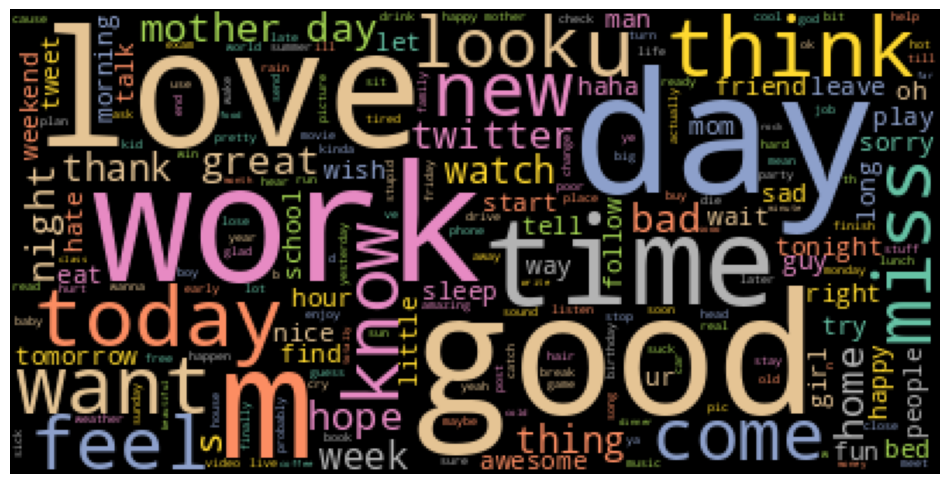

In [77]:
plt.figure(figsize = (12, 12), facecolor = None)
wc=WordCloud(colormap='Set2').generate(final_text)
plt.imshow(wc)
plt.axis("off")
plt.show()

## A Single function for pre-processing

In [ ]:
def pre_processing(input_data, text_col):
    input_data["text_col_clean"]=input_data[text_col].apply(lambda x:str(x).lower())  # lowecase conversion
    input_data["text_col_clean"]=input_data["text_col_clean"].apply(lambda x:[expanded_form(t) for t in str(x).split()])  # Tokenization or expansion of contractions
    input_data["text_col_clean"]=input_data["text_col_clean"].apply(lambda x:[t for t in x if t not in spacy_stopwords ])  # Removing Stopwords
    input_data["text_col_clean"]=input_data["text_col_clean"].apply(lambda x:clean_with_re(x))  # Cleaning with regex (removing punctuations, URLs, digits)
    input_data["text_col_clean"]=input_data["text_col_clean"].apply(lambda x:" ".join([t.lemma_ for t in spacy_model(str(x))if t.lemma_ !="-PRON-" ]))  # Lemmatization [if t.lemma_ !="-PRON-" to avoid pronouns : used in older versions of spacy]
    input_data["text_col_clean"]=input_data["text_col_clean"].apply(lambda x:[t for t in str(x).split() if t not in spacy_stopwords ]) # Removing stopwords after lemmatization
    input_data["text_col_clean"]=input_data["text_col_clean"].apply(lambda x: " ".join(x) )  # Final joining of tokens to form cleaned text
    print(input_data[[text_col,"text_col_clean"]])

In [79]:
pre_processing(input_data=twitter_data, text_col="raw_tweet")

                                               raw_tweet  \
0                    I`d have responded, if I were going   
1          Sooo SAD I will miss you here in San Diego!!!   
2                              my boss is bullying me...   
3                         what interview! leave me alone   
4       Sons of ****, why couldn`t they put them on t...   
...                                                  ...   
27476   wish we could come see u on Denver  husband l...   
27477   I`ve wondered about rake to.  The client has ...   
27478   Yay good for both of you. Enjoy the break - y...   
27479                         But it was worth it  ****.   
27480     All this flirting going on - The ATG smiles...   

                                          text_col_clean  
0                                              I respond  
1                                sooo sad miss san diego  
2                                           boss bully I  
3                                        in

## Document Term Matrix

Converting clean text data to numerical form

In [90]:
from sklearn.feature_extraction.text import CountVectorizer

countvec1 = CountVectorizer(min_df= 5) #minimum word freq=5
dtm_v1 = pd.DataFrame(countvec1.fit_transform(twitter_data['Final_Cleaned_Tweet_tokens']).toarray(), columns=countvec1.get_feature_names_out(), index=None)
print(dtm_v1.shape)
dtm_v1

(27481, 3468)


,aaaah,aah,abandon,ability,abit,able,absolutely,abt,ac,academy,...,yum,yummy,yup,zac,zealand,zero,zombie,zone,zoo,ï½
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27476,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27477,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27478,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27479,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
